In [3]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 28.2 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import yfinance as yf

In [6]:
# 데이터 수집
ticker = "005930.KS" # 삼성전자 예시
start_date = "2023-01-01"
end_date = "2025-12-31"

df = yf.download(ticker, start = start_date, end = end_date, auto_adjust = True)

[*********************100%***********************]  1 of 1 completed


In [7]:
type(df)

pandas.core.frame.DataFrame

In [8]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2023-01-02,51982.601562,52544.575633,51701.614527,51982.601562,10031448
2023-01-03,51888.949219,52450.923398,51045.987950,51888.949219,13547030
2023-01-04,54136.847656,54324.172389,52076.275600,52169.937966,20188071
2023-01-05,54511.488281,55073.462387,53949.514175,54511.488281,15682826
2023-01-06,55260.781250,55635.430614,54230.495498,54605.144862,17334989


In [9]:
df.isnull().sum()

Price   Ticker   
Close   005930.KS    0
High    005930.KS    0
Low     005930.KS    0
Open    005930.KS    0
Volume  005930.KS    0
dtype: int64

In [10]:
# 영업일 기준 일별 주가이므로 이번 예시에서는 5일 주기 사용
period = 5

In [11]:
# 가법 모형 분해
add_result = seasonal_decompose(
    df["Close"],
    model = "additive", # 가법 모형(기본값)
    period = period,
    extrapolate_trend = "freq" # trend의 양 끝단의 결측값을 채우는 방법 설정(freq : 선형 보간 추정값으로 채움)
)

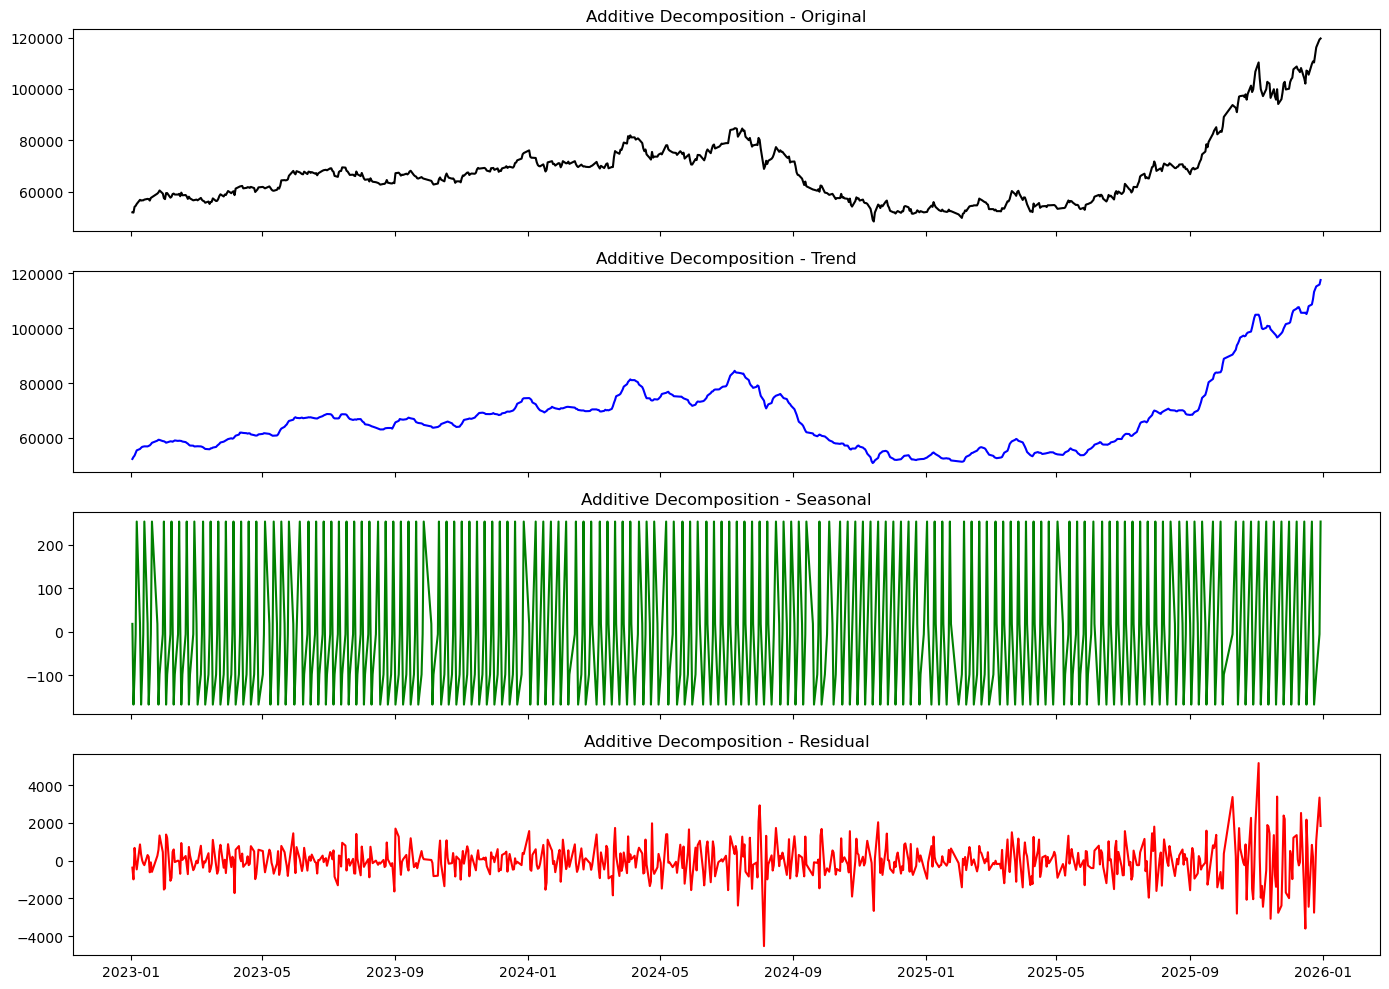

In [12]:
# 가법 모형 4단 그래프
fig, axes = plt.subplots(4, 1, figsize = (14, 10), sharex = True)

axes[0].plot(add_result.observed, color = "black")
axes[0].set_title("Additive Decomposition - Original")

axes[1].plot(add_result.trend, color = "blue")
axes[1].set_title("Additive Decomposition - Trend")

axes[2].plot(add_result.seasonal, color = "green")
axes[2].set_title("Additive Decomposition - Seasonal")

axes[3].plot(add_result.resid, color = "red")
axes[3].set_title("Additive Decomposition - Residual")

plt.tight_layout()
plt.show()

In [13]:
# 승법 모형 분해
mul_result = seasonal_decompose(
    df["Close"],
    model = "multiplicative", # 승법 모형
    period = period,
    extrapolate_trend = "freq" # trend의 양 끝단의 결측값을 채우는 방법 설정(freq : 선형 보간 추정값으로 채움)
)

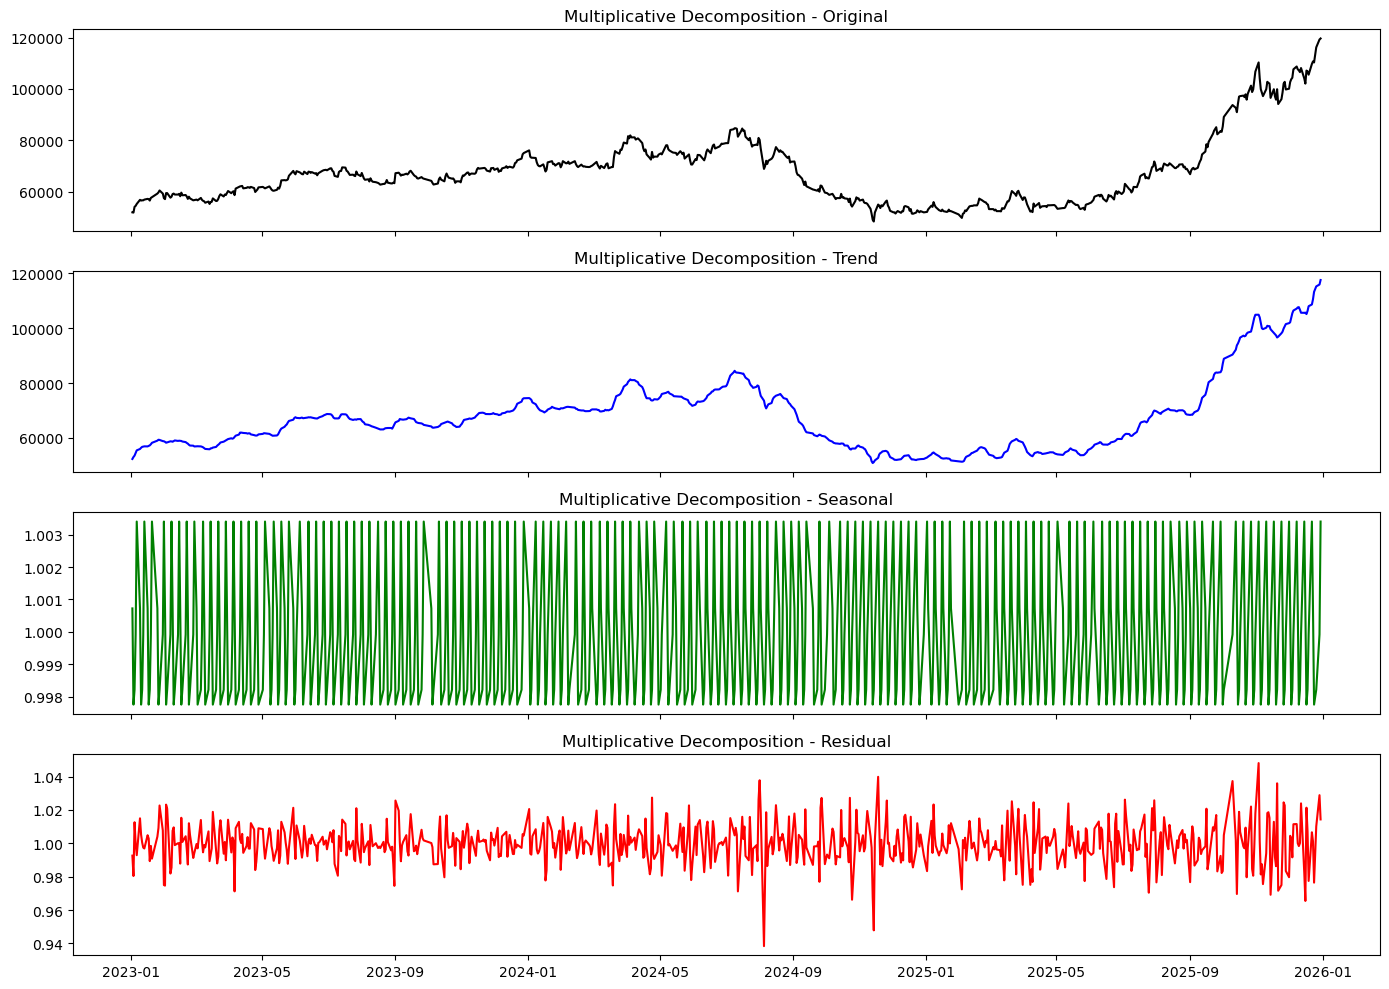

In [14]:
# 승법 모형 4단 그래프
fig, axes = plt.subplots(4, 1, figsize = (14, 10), sharex = True)

axes[0].plot(mul_result.observed, color = "black")
axes[0].set_title("Multiplicative Decomposition - Original")

axes[1].plot(mul_result.trend, color = "blue")
axes[1].set_title("Multiplicative Decomposition - Trend")

axes[2].plot(mul_result.seasonal, color = "green")
axes[2].set_title("Multiplicative Decomposition - Seasonal")

axes[3].plot(mul_result.resid, color = "red")
axes[3].set_title("Multiplicative Decomposition - Residual")

plt.tight_layout()
plt.show()